In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import zoom
import cv2
from torchvision import transforms as T
import torchvision.transforms as T
import numpy as np
import os
import torch
from common import *
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import PIL
import PIL.Image
import cv2
from kemsekov_torch.positional_emb import PositionalEncodingPermute
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import affine_transform
import random
import skimage.measure
from scipy.ndimage import rotate
from scipy.spatial.transform import Rotation
from scipy.ndimage import gaussian_filter
from torch.cuda.amp import GradScaler, autocast



/home/alexus/Desktop/For_Generator/kemsekov_torch/__pycache__/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
!nvidia-smi

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

In [ ]:

class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, info_dir, images_transform=None, projections_order=['a', 'b']):
        super().__init__()
        
        self.projections_order = projections_order
        
        # Считываем разметку
        labels = os.listdir(labels_dir)
        index_to_label = {i.split('.')[0]: os.path.join(labels_dir, i) for i in labels}
        
        # Считываем изображения
        images = os.listdir(images_dir)
        image_labels = [i.split("image")[1].split(".")[0] for i in images]
        
        data = {}
        for image, label in zip(images, image_labels):
            label_index = label[:-1]
            label_letter = label[-1]
            if label_index not in data:
                data[label_index] = {}
            data[label_index][label_letter] = os.path.join(images_dir, image)
        
        # Добавляем метки и проекции
        for i in index_to_label:
            row = data[i]
            row['label'] = index_to_label[i]
            projections = [row[p] for p in projections_order]
            row['projections'] = projections
        
        # Загружаем углы проекций из info файлов
        self.angles = {}
        info_files = os.listdir(info_dir)
        for info_file in info_files:
            if info_file.endswith(".info.0"):  # Фильтруем нужные файлы
                info_path = os.path.join(info_dir, info_file)
                with open(info_path, 'r') as f:
                    info_data = json.load(f)
                case_id = info_file.split('.')[0]  # ID кейса
                self.angles[case_id] = {
                    'theta': info_data.get("theta_array", []),
                    'phi': info_data.get("phi_array", [])
                }
        
        self.data = data
        self.keys = list(self.data.keys())
        self.images_transform = images_transform if images_transform else lambda x: T.ToTensor()(x)
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, index):
        key = self.keys[index]
        row = self.data[key]
        label = np.load(row['label'])
        images = [PIL.Image.open(v) for v in row['projections']]
        images = torch.concat([self.images_transform(i) for i in images])
        
        # Получаем углы для данного случая
        angles = self.angles.get(key, {'theta': [0] * len(self.projections_order), 'phi': [0] * len(self.projections_order)})
        theta = torch.tensor(angles['theta'], dtype=torch.float32)
        phi = torch.tensor(angles['phi'], dtype=torch.float32)
        
        return images, torch.tensor(label), theta, phi

In [ ]:
# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d2 = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

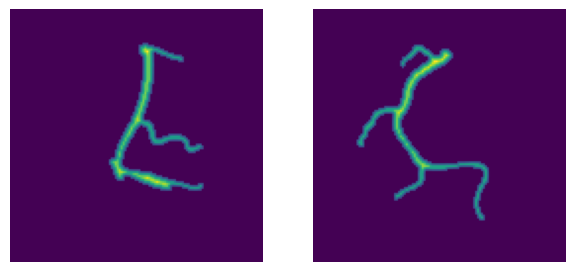

In [27]:
sample_index = 2 #random.randint(0,len(d)-1)
sample = d2[sample_index] #d2[1]
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(sample[0][0]) #d2[1][0][0]
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(sample[0][1])
plt.axis('off')

In [ ]:
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy() #d2[1][0]
proj2 = images[1].cpu().numpy()
proj2.shape

In [41]:
output_3d_model = sample[1].numpy() 
output_3d_model.shape

(4, 300, 4)

In [ ]:
# Нормализация 3D модели
def normalize_tensor(sample):
    centerline_copy = sample.copy()
    slice = centerline_copy[..., :3]
    scale = slice.max() - slice.min()
    centerline_copy[..., :3] -= slice.min()
    centerline_copy[..., :3] /= scale if scale != 0 else 1
    centerline_copy[..., -1] /= scale if scale != 0 else 1
    return centerline_copy

output_3d_model = normalize_tensor(output_3d_model)
print("output_3d_model shape after normalize:", output_3d_model.shape)

# Создание target_3d с использованием старого метода
volume_shape = (128, 128, 128)
T = torch.zeros(volume_shape, dtype=torch.float32)

for group in range(output_3d_model.shape[0]):
    x = (output_3d_model[group, :, 0] * 100 + 10).astype(int).clip(0, 127)
    y = (output_3d_model[group, :, 1] * 100 + 10).astype(int).clip(0, 127)
    z = (output_3d_model[group, :, 2] * 100 + 10).astype(int).clip(0, 127)
    R = torch.tensor(output_3d_model[group, :, 3], dtype=torch.float32) * 10
    print(f"Group {group} R min, max:", R.min().item(), R.max().item())
    
    for i in range(len(x)):
        radius = int((R[i] * 12).clamp(1, 10))
        x_grid, y_grid, z_grid = torch.meshgrid(
            torch.arange(-radius, radius + 1),
            torch.arange(-radius, radius + 1),
            torch.arange(-radius, radius + 1)
        )
        mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
        x_shifted = x[i] + x_grid[mask]
        y_shifted = y[i] + y_grid[mask]
        z_shifted = z[i] + z_grid[mask]
        valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
        x_valid, y_valid, z_valid = x_shifted[valid], y_shifted[valid], z_shifted[valid]
        for x_v, y_v, z_v in zip(x_valid, y_valid, z_valid):
            if T[x_v, y_v, z_v] == 0:
                T[x_v, y_v, z_v] = R[i]
            else:
                T[x_v, y_v, z_v] = (T[x_v, y_v, z_v] + R[i]) / 2

# Назначим T как target_3d
target_3d = T / T.max() if T.max() > 0 else T
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_3d = torch.unsqueeze(torch.unsqueeze(target_3d, 0), 0).to(device)
print("target_3d final shape:", target_3d.shape)

# Создание "теней" (backprojection)
phi1, phi2, theta1, theta2 = -40.0, 75.0, -10.0, -10.0
volume_shape = (128, 128, 128)

def create_shadow(projection, phi, theta, volume_shape=(128, 128, 128)):
    D_x, D_y, D_z = volume_shape
    # Убедимся, что проекция — бинарная (0 или 1)
    #projection = (projection > 0).float()  # На случай, если остались небольшие значения
    # Масштабируем проекцию до размеров D_x, D_y
    projection = zoom(projection, (D_x / projection.shape[0], D_y / projection.shape[1]), order=1)
    projection = torch.tensor(projection, dtype=torch.float32)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = projection
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    phi_rad, theta_rad = torch.tensor(np.radians(phi)), torch.tensor(np.radians(theta))
    dx = torch.sin(theta_rad) * torch.cos(phi_rad)
    dy = torch.sin(theta_rad) * torch.sin(phi_rad)
    dz = -torch.cos(theta_rad)
    norm = torch.sqrt(dx**2 + dy**2 + dz**2)
    dx, dy, dz = dx / norm, dy / norm, dz / norm
    z_indices = torch.arange(D_z, dtype=torch.long)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for i in range(len(x_coords)):
        for j in range(D_z):
            if shadow_z[i, j] < D_z:
                vol[shadow_y[i, j], shadow_x[i, j], shadow_z[i, j]] = intensities[i]
    return vol

shadow1 = create_shadow(proj1, phi1, theta1, volume_shape)
shadow2 = create_shadow(proj2, phi2, theta2, volume_shape)
print("shadow1 shape:", shadow1.shape)
print("shadow2 shape:", shadow2.shape)
backprojection = shadow1 + shadow2
backprojection = backprojection / backprojection.max() if backprojection.max() > 0 else backprojection
backprojection = torch.unsqueeze(torch.unsqueeze(backprojection, 0), 0).to(device)
print("backprojection shape:", backprojection.shape)

# Визуализация target_3d, shadow1 и shadow2
def visualize_3d_volume(volume, title="3D Reconstruction"):
    nonzero_indices = (volume > 0.01).nonzero(as_tuple=False)
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = volume[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Value"))
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show()
    else:
        print(f"No significant nonzero values (> 0.001) in {title} to visualize!")

# Визуализация
print("Visualizing target_3d...")
visualize_3d_volume(target_3d.squeeze().squeeze(), title="Original 3D Target")
print("Visualizing shadow1...")
visualize_3d_volume(shadow1, title="Shadow 1")
print("Visualizing shadow2...")
visualize_3d_volume(shadow2, title="Shadow 2")

In [ ]:

from skimage.measure import marching_cubes

import os

def visualize_3d_volumes_marching_cubes(volumes, titles, threshold=0.1):
    fig = go.Figure()
    colors = ['blue', 'red', 'green']  # Цвета для shadow1, shadow2, backprojection
    for i, volume in enumerate(volumes):
        # Переносим тензор на CPU перед преобразованием в numpy
        volume_np = volume.cpu().squeeze().squeeze().numpy()
        try:
            # Извлекаем изометрическую поверхность с помощью marching_cubes
            verts, faces, normals, values = marching_cubes(volume_np, level=threshold, spacing=(1.0, 1.0, 1.0))
            fig.add_trace(go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                color=colors[i], opacity=0.5,
                name=titles[i]
            ))
        except ValueError as e:
            print(f"Ошибка при построении поверхности для {titles[i]}: {e}")
            print(f"Проверьте значения в {titles[i]}. Min: {volume_np.min()}, Max: {volume_np.max()}")
    fig.update_layout(
        title="Combined 3D Reconstruction (Marching Cubes)",
        scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
        width=700, height=700,
        template="plotly_dark",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.show()
visualize_3d_volumes_marching_cubes([shadow1, shadow2, backprojection.squeeze().squeeze()], 
                                   titles=["Shadow 1", "Shadow 2", "Backprojection"], 
                                   threshold=0.1)

In [ ]:
# Трансформерный слой
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.ReLU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        batch, channels, D, H, W = x.size()
        print(f"TransformerBlock input shape: {x.shape}")
        assert channels == self.attn.embed_dim, f"Channels ({channels}) must match embed_dim ({self.attn.embed_dim})"
        seq_len = D * H * W
        x_flat = x.view(batch * seq_len, channels)
        print(f"x_flat shape: {x_flat.shape}")
        attn_output, _ = self.attn(x_flat.unsqueeze(0), x_flat.unsqueeze(0), x_flat.unsqueeze(0))
        attn_output = attn_output.squeeze(0)
        print(f"attn_output shape: {attn_output.shape}")
        x = x_flat + attn_output
        x = self.norm1(x)
        print(f"x shape after norm1: {x.shape}")
        mlp_output = self.mlp(x)
        print(f"mlp_output shape: {mlp_output.shape}")
        x = self.norm2(x + mlp_output)
        x = x.view(batch, seq_len, channels)
        x = x.transpose(1, 2)
        x = x.view(batch, channels, D, H, W)
        print(f"TransformerBlock output shape: {x.shape}")
        return x

# Генератор
class DeepCAGenerator(nn.Module):
    def __init__(self):
        super(DeepCAGenerator, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = nn.Sequential(
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool3d(2)
        self.enc4 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU()
        )
        self.pool4 = nn.MaxPool3d(2)
        self.transformer = TransformerBlock(dim=64)
        self.upconv5 = nn.ConvTranspose3d(64, 64, kernel_size=2, stride=2)
        self.dec5 = nn.Sequential(
            nn.Conv3d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU()
        )
        self.upconv4 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv3d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )
        self.upconv3 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv3d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU()
        )
        self.upconv2 = nn.ConvTranspose3d(16, 8, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv3d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU()
        )
        self.upconv1 = nn.ConvTranspose3d(8, 4, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv3d(5, 4, kernel_size=3, padding=1),
            nn.BatchNorm3d(4),
            nn.ReLU(),
            nn.Conv3d(4, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
        self.alpha = torch.nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        print("Input shape:", x.shape)
        e1 = self.enc1(x)
        print("e1 shape:", e1.shape)
        p1 = self.pool1(e1)
        print("p1 shape:", p1.shape)
        e2 = self.enc2(p1)
        print("e2 shape:", e2.shape)
        p2 = self.pool2(e2)
        print("p2 shape:", p2.shape)
        e3 = self.enc3(p2)
        print("e3 shape:", e3.shape)
        p3 = self.pool3(e3)
        print("p3 shape:", p3.shape)
        e4 = self.enc4(p3)
        print("e4 shape:", e4.shape)
        p4 = self.pool4(e4)
        print("p4 shape before transformer:", p4.shape)
        t = self.transformer(p4)
        print("t shape after transformer:", t.shape)
        d5 = self.upconv5(t)
        d5 = self.dec5(d5)
        d4 = self.upconv4(d5)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)
        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)
        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)
        d1 = self.upconv1(d2)
        d1 = F.interpolate(d1, size=(128, 128, 128), mode='trilinear', align_corners=False)
        d1 = torch.cat([d1, x], dim=1)
        out = self.dec1(d1)
        return out

# Критик
class DeepCACritic(nn.Module):
    def __init__(self):
        super(DeepCACritic, self).__init__()
        self.conv1 = nn.Conv3d(1, 8, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv3d(8, 16, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc = nn.Linear(64 * 8 * 8 * 8, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# WGAN-GP обучение
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = DeepCAGenerator().to(device)
critic = DeepCACritic().to(device)
optim_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(critic.parameters(), lr=0.0002, betas=(0.5, 0.999))
lambda_gp = 10
n_critic = 5
scaler = GradScaler()

def compute_gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, 1, device=device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(batch_size, 1, device=device)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# Обучение
num_epochs = 1000
for epoch in range(num_epochs):
    for _ in range(n_critic):
        optim_D.zero_grad()
        with autocast():
            real = target_3d
            fake = generator(backprojection)
            d_real = critic(real)
            d_fake = critic(fake.detach())
            gradient_penalty = compute_gradient_penalty(critic, real, fake, device)
            d_loss = -torch.mean(d_real) + torch.mean(d_fake) + lambda_gp * gradient_penalty
        scaler.scale(d_loss).backward()
        scaler.step(optim_D)
        scaler.update()

    optim_G.zero_grad()
    with autocast():
        fake = generator(backprojection)
        g_loss = -torch.mean(critic(fake)) + F.mse_loss(fake, target_3d)
    scaler.scale(g_loss).backward()
    scaler.step(optim_G)
    scaler.update()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

generator.eval()
with torch.no_grad():
    predicted = generator(backprojection).squeeze(0).squeeze(0)
    print("Shape of predicted:", predicted.shape)
    print("Max value in predicted:", predicted.max().item())
    print("Min value in predicted:", predicted.min().item())
    nonzero_indices = (predicted > 0.001).nonzero(as_tuple=False)
    print("Number of nonzero points in predicted (threshold > 0.001):", len(nonzero_indices))
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = predicted[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Predicted Value"))
        )])
        fig.update_layout(
            title="Predicted 3D Reconstruction",
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show() 
    else:
        print("No significant nonzero values (> 0.001) in predicted tensor to visualize!")

In [ ]:
def visualize_3d_volume(volume, title="3D Reconstruction", threshold=0.1):
    # Убеждаемся, что volume - это тензор формы (D, H, W)
    volume = volume.squeeze().squeeze()  # Удаляем лишние измерения
    nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = volume[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Value"))
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show()
    else:
        print(f"No significant nonzero values (> {threshold}) in {title} to visualize!")

visualize_3d_volume(predicted)

In [39]:
proj1

array([[0.25000003, 0.25000003, 0.25000003, ..., 0.25000003, 0.25000003,
        0.25000003],
       [0.25000003, 0.25      , 0.25      , ..., 0.25      , 0.25      ,
        0.25      ],
       [0.25000003, 0.25      , 0.25      , ..., 0.25      , 0.25      ,
        0.25      ],
       ...,
       [0.25000003, 0.25      , 0.25      , ..., 0.25      , 0.25      ,
        0.25      ],
       [0.25000003, 0.25      , 0.25      , ..., 0.25      , 0.25      ,
        0.25      ],
       [0.25000003, 0.25      , 0.25      , ..., 0.25      , 0.25      ,
        0.25      ]], dtype=float32)

In [ ]:
def get_3d_tensors(projection1 = proj1,projection2 = proj2,correct_3d_geometry = ,tensor_output_shape=(128,128,128)):
    """
    Из двух двумерных проекций `projection1` (1,128,128), `projection2` (1,128,128) строит трехмерный тензор размером `tensor_output_shape` который содержит в себе тени от
    двумерных проекций.

    Из информации о ветках `correct_3d_geometry` (4,300,4) строит 3д тензор

    Возвращает два 3д тенозора размером `tensor_output_shape`, первый из которых - тензор теней, второй - тензор с 3д геометрией
    """

    
    pass

class BackprojectionDataset(torch.utils.data.Dataset):
    def __init__(self,two_proj_3d_dataset):
        super().__init__()
        self.two_proj_3d_dataset=two_proj_3d_dataset
    def __len__(self):
        return len(self.two_proj_3d_dataset)
    def __getitem__(self, index):
        
        sample = self.two_proj_3d_dataset[index]
        #sample[0] is two 2d projections
        #sample[1] is 3d

        # construct two 3d tensors
        # return
        return get_3d_tensors(...)


In [ ]:
from kemsekov_torch.residual import ResidualBlock
from kemsekov_torch.train import train,split_dataset

# Улучшенная модель с U-Net элементами
class UNet3D(nn.Module):
    def __init__(self,in_channels,out_channels):
        super(UNet3D, self).__init__()
        common = dict(stride=2, dimensions=3,x_residual_type='conv')
        self.enc1 = ResidualBlock(in_channels=in_channels, out_channels=8, **common)
        self.enc2 = ResidualBlock(in_channels=8, out_channels=16,**common)
        self.enc3 = ResidualBlock(in_channels=16, out_channels=32,**common)

        self.dec1 = ResidualBlock(in_channels=32, out_channels=16,**common).transpose()
        self.dec2 = ResidualBlock(in_channels=16, out_channels=8,**common).transpose()
        self.dec3 = ResidualBlock(in_channels=8, out_channels=out_channels,**common).transpose()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d1 = self.dec1(e3) + e2  # Skip connection
        d2 = self.dec2(d1) + e1  # Skip connection
        d3 = self.dec3(d2)
        return d3
def mse(x,y): return torch.mean((x-y)**2)

def compute_loss_and_metric(model,batch):
    input,output = batch[0],batch[1]
    return mse(model(input),output),{
        "r2":1
    }

train_d,test_d ,_,_ = split_dataset(d2)

train_d = BackprojectionDataset(train_d)
test_d = BackprojectionDataset(test_d)
# two_proj_tensor = torch.randn((1,2,128,128,128))
# corect_answer_tensor = torch.randn((1,1,128,128,128))


model = UNet3D(2,1)
train(
    model,
    train_d,
    test_d,
    compute_loss_and_metric
)


(<torch.utils.data.dataset.Subset at 0x7445ac7c5f10>,
 <torch.utils.data.dataloader.DataLoader at 0x744580407590>)

# КОД ОТ ГРОКА

тест

In [ ]:
split_dataset

NameError: name 'split_dataset' is not defined

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# Трансформерный слой
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.ReLU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        batch, channels, D, H, W = x.size()
        print(f"TransformerBlock input shape: {x.shape}")
        assert channels == self.attn.embed_dim, f"Channels ({channels}) must match embed_dim ({self.attn.embed_dim})"
        seq_len = D * H * W
        x_flat = x.view(batch * seq_len, channels)
        print(f"x_flat shape: {x_flat.shape}")
        attn_output, _ = self.attn(x_flat.unsqueeze(0), x_flat.unsqueeze(0), x_flat.unsqueeze(0))
        attn_output = attn_output.squeeze(0)
        print(f"attn_output shape: {attn_output.shape}")
        x = x_flat + attn_output
        x = self.norm1(x)
        print(f"x shape after norm1: {x.shape}")
        mlp_output = self.mlp(x)
        print(f"mlp_output shape: {mlp_output.shape}")
        x = self.norm2(x + mlp_output)
        x = x.view(batch, seq_len, channels)
        x = x.transpose(1, 2)
        x = x.view(batch, channels, D, H, W)
        print(f"TransformerBlock output shape: {x.shape}")
        return x

class DeepCAGenerator(nn.Module):
    def __init__(self):
        super(DeepCAGenerator, self).__init__()
        # Энкодер
        self.enc1 = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool3d(2)  # 128 -> 64
        self.enc2 = nn.Sequential(
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool3d(2)  # 64 -> 32
        self.enc3 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool3d(2)  # 32 -> 16
        self.enc4 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU()
        )
        self.pool4 = nn.MaxPool3d(2)  # 16 -> 8

        # Трансформер
        self.transformer = TransformerBlock(dim=64)

        # Декодер
        self.upconv5 = nn.ConvTranspose3d(64, 64, kernel_size=2, stride=2)  # 8 -> 16
        self.dec5 = nn.Sequential(
            nn.Conv3d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU()
        )
        self.upconv4 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)  # 16 -> 32
        self.dec4 = nn.Sequential(
            nn.Conv3d(32, 32, kernel_size=3, padding=1),  # Теперь 32, а не 64, т.к. сложение
            nn.BatchNorm3d(32),
            nn.ReLU()
        )
        self.upconv3 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)  # 32 -> 64
        self.dec3 = nn.Sequential(
            nn.Conv3d(16, 16, kernel_size=3, padding=1),  # Теперь 16, а не 32
            nn.BatchNorm3d(16),
            nn.ReLU()
        )
        self.upconv2 = nn.ConvTranspose3d(16, 8, kernel_size=2, stride=2)  # 64 -> 128
        self.dec2 = nn.Sequential(
            nn.Conv3d(8, 8, kernel_size=3, padding=1),  # Теперь 8, а не 16
            nn.BatchNorm3d(8),
            nn.ReLU()
        )
        self.upconv1 = nn.ConvTranspose3d(8, 4, kernel_size=2, stride=2)  # Предполагаем 128 на выходе после интерполяции
        self.dec1 = nn.Sequential(
            nn.Conv3d(4, 4, kernel_size=3, padding=1),  # Теперь 4, т.к. сложение с проекцией входа
            nn.BatchNorm3d(4),
            nn.ReLU(),
            nn.Conv3d(4, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

        # Обучаемые параметры alpha для каждого skip connection
        self.alpha4 = nn.Parameter(torch.tensor(1.0))  # Для e3 + d4
        self.alpha3 = nn.Parameter(torch.tensor(1.0))  # Для e2 + d3
        self.alpha2 = nn.Parameter(torch.tensor(1.0))  # Для e1 + d2
        self.alpha1 = nn.Parameter(torch.tensor(1.0))  # Для x + d1

    def forward(self, x):
        # Энкодер
        e1 = self.enc1(x)  # [B, 8, 128, 128, 128]
        p1 = self.pool1(e1)  # [B, 8, 64, 64, 64]
        e2 = self.enc2(p1)  # [B, 16, 64, 64, 64]
        p2 = self.pool2(e2)  # [B, 16, 32, 32, 32]
        e3 = self.enc3(p2)  # [B, 32, 32, 32, 32]
        p3 = self.pool3(e3)  # [B, 32, 16, 16, 16]
        e4 = self.enc4(p3)  # [B, 64, 16, 16, 16]
        p4 = self.pool4(e4)  # [B, 64, 8, 8, 8]

        # Трансформер
        t = self.transformer(p4)  # [B, 64, 8, 8, 8]

        # Декодер с skip connections
        d5 = self.upconv5(t)  # [B, 64, 16, 16, 16]
        d5 = self.dec5(d5)  # [B, 64, 16, 16, 16]

        d4 = self.upconv4(d5)  # [B, 32, 32, 32, 32]
        d4 = self.alpha4 * self.dec4(d4) + e3  # Skip connection: alpha4 * conv(d4) + e3

        d3 = self.upconv3(d4)  # [B, 16, 64, 64, 64]
        d3 = self.alpha3 * self.dec3(d3) + e2  # Skip connection: alpha3 * conv(d3) + e2

        d2 = self.upconv2(d3)  # [B, 8, 128, 128, 128]
        d2 = self.alpha2 * self.dec2(d2) + e1  # Skip connection: alpha2 * conv(d2) + e1

        d1 = self.upconv1(d2)  # [B, 4, 256, 256, 256] (если stride=2 увеличивает в 2 раза)
        d1 = F.interpolate(d1, size=(128, 128, 128), mode='trilinear', align_corners=False)  # [B, 4, 128, 128, 128]
        
        # Проекция входа x для совпадения каналов (1 -> 4)
        x_proj = nn.Conv3d(1, 4, kernel_size=1).to(x.device)(x)  # [B, 4, 128, 128, 128]
        d1 = self.alpha1 * self.dec1[:-2](d1) + x_proj  # Применяем conv и bn из dec1 до последнего слоя
        out = self.dec1[-2:](d1)  # Последние слои: conv и sigmoid

        return out
    

In [22]:
# Критик
class DeepCACritic(nn.Module):
    def __init__(self):
        super(DeepCACritic, self).__init__()
        self.conv1 = nn.Conv3d(1, 8, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv3d(8, 16, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc = nn.Linear(64 * 8 * 8 * 8, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# WGAN-GP обучение
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = DeepCAGenerator().to(device)
critic = DeepCACritic().to(device)
optim_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(critic.parameters(), lr=0.0002, betas=(0.5, 0.999))
lambda_gp = 10
n_critic = 5
scaler = GradScaler()

def compute_gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, 1, device=device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(batch_size, 1, device=device)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# Обучение
num_epochs = 1000
for epoch in range(num_epochs):
    for _ in range(n_critic):
        optim_D.zero_grad()
        with autocast():
            real = target_3d
            fake = generator(backprojection)
            d_real = critic(real)
            d_fake = critic(fake.detach())
            gradient_penalty = compute_gradient_penalty(critic, real, fake, device)
            d_loss = -torch.mean(d_real) + torch.mean(d_fake) + lambda_gp * gradient_penalty
        scaler.scale(d_loss).backward()
        scaler.step(optim_D)
        scaler.update()

    optim_G.zero_grad()
    with autocast():
        fake = generator(backprojection)
        g_loss = -torch.mean(critic(fake)) + F.mse_loss(fake, target_3d)
    scaler.scale(g_loss).backward()
    scaler.step(optim_G)
    scaler.update()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

generator.eval()
with torch.no_grad():
    predicted = generator(backprojection).squeeze(0).squeeze(0)
    print("Shape of predicted:", predicted.shape)
    print("Max value in predicted:", predicted.max().item())
    print("Min value in predicted:", predicted.min().item())
    nonzero_indices = (predicted > 0.001).nonzero(as_tuple=False)
    print("Number of nonzero points in predicted (threshold > 0.001):", len(nonzero_indices))
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = predicted[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Predicted Value"))
        )])
        fig.update_layout(
            title="Predicted 3D Reconstruction",
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show() 
    else:
        print("No significant nonzero values (> 0.001) in predicted tensor to visualize!")

/tmp/ipykernel_7068/2618638242.py:27: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

/tmp/ipykernel_7068/2618638242.py:52: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.

/tmp/ipykernel_7068/2618638242.py:64: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.Size([512, 64])
mlp_output shape: torch.Size([512, 64])
TransformerBlock output shape: torch.Size([1, 64, 8, 8, 8])
TransformerBlock input shape: torch.Size([1, 64, 8, 8, 8])
x_flat shape: torch.Size([512, 64])
attn_output shape: torch.Size([512, 64])
x shape after norm1: torch.

KeyboardInterrupt: 

In [ ]:
def visualize_3d_volume(volume, title="3D Reconstruction", threshold=0.1):
    # Убеждаемся, что volume - это тензор формы (D, H, W)
    volume = volume.squeeze().squeeze()  # Удаляем лишние измерения
    nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = volume[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Value"))
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show()
    else:
        print(f"No significant nonzero values (> {threshold}) in {title} to visualize!")

visualize_3d_volume(predicted)